In [4]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import pairwise

In [5]:
class Interval:

    def __init__(self, start: float, end: float):
        if start >= end: raise Exception(f"intervals must be valid and non-empty, found [{start}, {end}[, they all are semi-open [a, b[, a < b")
        self.set_start(start)
        self.set_end(end)

    def __contains__(self, item: float) -> bool:
        return self.start <= item < self.end

    def __repr__(self) -> str:
        return f"[{self.start}, {self.end}["

    def get_start(self) -> float:
        return self.start

    def get_end(self) -> float:
        return self.end

    def set_start(self, new_start: float) -> None:
        self.start = new_start

    def set_end(self, new_end: float) -> None:
        self.end = new_end

In [12]:
class HullByParts:

    def __init__(self, reference_function, subfunctions_to_intervals = {}, function_range = None):
        self.f: callable[float, float] = reference_function
        self.subfunctionIntervals: dict[tuple, list[Interval]] = subfunctions_to_intervals
        self.set_range(function_range)

        self.verify_validity()

        self.sanitize_subfunctions()
        self.sanitize_intervals()
        if function_range is None: self.set_range(self.infer_range())


    ############### Callers #########################

    def __call__(self, x: float|list[float]|np.ndarray) -> float|np.ndarray:
        if isinstance(x, float):return self.call_float(x)
        else:                   return self.call_iter(x) 

    def call_iter(self, l) -> np.ndarray:
        return np.array(list(map(lambda x: self.call_float(x), l)))
    
    def call_float(self, x: float) -> float:
        for (slope, x_intercept), intervals in self.get_subfunctionIntervals().items():
            for interval in intervals:
                if x in interval:
                    return self.f(slope * (x - x_intercept))
        raise Exception(f"could not find {x} in the definition set of the function")


    ################# getters, setters, basic adders #####################

    def get_range(self) -> Interval:
        return self.f_range

    def set_range(self, interval: Interval) -> None:
        self.f_range = interval

    def get_all_intervals(self) -> list[Interval]:
        return [inter for list_inter in self.get_subfunctionIntervals().values() for inter in list_inter]

    def get_subfunctionIntervals(self) -> dict[tuple, list[Interval]]:
        return self.subfunctionIntervals

    def add_subfunctionInterval(self, params, interval):
        if params in self.get_subfunctionIntervals():
            self.subfunctionIntervals[params].append(interval)
        else:
            self.subfunctionIntervals[params] = [interval]


    #################### sanitizers ########################

    def sanitize_subfunctions(self) -> None:
        for (s, x), inters in self.get_subfunctionIntervals().items():
            if s < 0:
                del self.subfunctionIntervals[(s, x)]
                self.subfunctionIntervals[(-s, -x)] = inters

    def sanitize_intervals(self) -> None:
        for inters in self.get_subfunctionIntervals().values():
            inters.sort(key=lambda i: i.get_start())

            i = 0
            while i < len(inters) - 1:
                if inters[i].get_end() == inters[i+1].get_start():
                    inters[i].set_end(inters[i+1].get_end())
                    del inters[i+1]
                else:
                    i += 1

    def infer_range(self) -> Interval:
            all_intervals = self.get_all_intervals()
            return Interval(min(all_intervals, key=lambda i: i.get_start()).get_start(), max(all_intervals, key=lambda i: i.get_end()).get_end())

    @staticmethod
    def sanitize_parameters(params: tuple[float, float]) -> tuple[float, float]:
        s, x = params
        if s < 0:   s, x = -s, -x
        elif s == 0: raise Exception("slope must not be 0, subfunctions must be bijective on R")

        return s, x

    ###################### verifiers #############################

    def verify_slope(self) -> None:
        for (s, _) in self.get_subfunctionIntervals().keys():
            if s == 0:
                raise Exception("slope must not be 0, subfunctions must be bijective on R")

    def verify_defined_on_all_interval(self) -> None:
        sorted_intervals = sorted(self.get_all_intervals(), key = lambda inter: inter.get_start())

        if sorted_intervals == [] and self.get_range() is not None: 
            raise Exception("the function cannot be defined on a non-empty range with no values for it")
        if sorted_intervals != [] and self.get_range() is not None and (self.get_range().get_start() != sorted_intervals[0].get_start() or self.get_range().get_end() != sorted_intervals[-1].get_end()):
            raise Exception("the function must be defined on its entire range, ends do not match")

        for inter1, inter2 in pairwise(sorted_intervals):
            if inter1.get_end() != inter2.get_start(): raise Exception("the function should be defined on the total range it takes values in")

    def verify_validity(self) -> None:
        self.verify_slope()
        self.verify_defined_on_all_interval()


    ##################### complex adders #################

    def left_right_intersections(self, parameters: tuple[float, float]) -> tuple[list, list, list]:
        a, b = parameters
        get_keys = self.get_subfunctionIntervals().keys()

        curbs_sorting_key = lambda k: k[1]
        left_curbs_params = sorted([k for k in get_keys if k[1] < b], key=curbs_sorting_key, reverse=True)
        right_curbs_params = sorted([k for k in get_keys if k[1] > b], key=curbs_sorting_key)
        
        useful_intersections_left = []
        useful_intersections_right = []
        considered_curbs = []

        for curbs_params in [left_curbs_params, right_curbs_params]:
            current_min_slope = a
            activate_skip = False
            for params in curbs_params:
                if params[0] >= current_min_slope and activate_skip: continue
                
                considered_curbs.append(params)
                if params[0] <= current_min_slope: 
                    current_min_slope = params[0]
                    if not activate_skip: activate_skip = True

                intervals = self.get_subfunctionIntervals()[params]
                intersections = HullByParts.intersection_points(parameters, params)
                
                for i, intersection in enumerate(intersections):
                    for interval in intervals:
                        if intersection in interval:
                            if intersection < b:
                                useful_intersections_left.append((params, i == 0, intersection, interval))
                            else:
                                useful_intersections_right.append((params, i == 0, intersection, interval))

        sorting_key = lambda x: x[2]
        useful_intersections_left.sort(key = sorting_key, reverse=True)
        useful_intersections_right.sort(key = sorting_key)
        return useful_intersections_left, useful_intersections_right, considered_curbs

    def process_intersections_left(self, parameters: tuple[float, float], 
                                   useful_intersections_left: tuple[any, bool, float, Interval], 
                                   new_intervals: list[tuple[float, float]]) -> None:
        _, intersection_to_remember = parameters
        for _, is_opposite, intersection, interval in useful_intersections_left:
            if is_opposite:
                interval.set_end(intersection)
                new_intervals.append((intersection, intersection_to_remember))
                self.add_subfunctionInterval(parameters, Interval(intersection, intersection_to_remember))
                intersection_to_remember = None
            else:
                interval.set_start(intersection)
                intersection_to_remember = intersection
        if intersection_to_remember is not None:
            self.add_subfunctionInterval(parameters, Interval(self.get_range().get_start(), intersection_to_remember))

    def process_intersections_right(self, parameters: tuple[float, float], 
                                   useful_intersections_right: tuple[any, bool, float, Interval], 
                                   new_intervals: list[tuple[float, float]]) -> None:
        _, intersection_to_remember = parameters
        for _, is_opposite, intersection, interval in useful_intersections_right:
            if is_opposite:
                interval.set_start(intersection)
                new_intervals.append((intersection_to_remember, intersection))
                self.add_subfunctionInterval(parameters, Interval(intersection_to_remember, intersection))
                intersection_to_remember = None
            else:
                interval.set_end(intersection)
                intersection_to_remember = intersection
        if intersection_to_remember is not None:
            self.add_subfunctionInterval(parameters, Interval(intersection_to_remember, self.get_range().get_end()))

    def add_subfunction(self, parameters: tuple[float, float]) -> None:
        a, b = parameters = HullByParts.sanitize_parameters(parameters)
        get_keys = self.get_subfunctionIntervals().keys()
        if b in [x_intercept for _, x_intercept in get_keys]: return#TODO

        useful_intersections_left, useful_intersections_right, considered_curbs = self.left_right_intersections((a, b))
        new_intervals = []
        self.process_intersections_left(parameters, useful_intersections_left, new_intervals)
        self.process_intersections_right(parameters, useful_intersections_right, new_intervals)

        self.delete_superfluous_intervals(considered_curbs, new_intervals)
        self.verify_validity()
        self.sanitize_intervals()
        

    def delete_superfluous_intervals(self, curbs, new_intervals):
        intervals_to_delete = set()
        for curb in curbs:
            for interval in self.get_subfunctionIntervals()[curb]:
                for start, end in new_intervals:
                    if start < interval.get_start() < end or start < interval.get_end() < end:
                        intervals_to_delete.add((curb, interval))

        for params, interval in intervals_to_delete:
            self.get_subfunctionIntervals()[params].remove(interval)

    @staticmethod
    def intersection_points(g, h):
        g_slope, g_x_inter = g
        h_slope, h_x_inter = h

        opposite_intersect = (g_x_inter*g_slope + h_x_inter*h_slope)/(g_slope + h_slope)
        if g_slope - h_slope == 0:  return [opposite_intersect]

        concurrent_intersect = (g_x_inter*g_slope - h_x_inter*h_slope)/(g_slope - h_slope)
        return [opposite_intersect, concurrent_intersect]
        


In [ ]:
def plot_draw(ax, x, hull, draw_value_curves = True):
    ax.set_ylim((0, 4))
    ax.set_xlim((0, 11))

    if draw_value_curves:
        for (slope, x_intercept) in hull.get_subfunctionIntervals():
            func = lambda x: hull.f(slope * (x - x_intercept))
            ax.plot(x, func(x), color = 'black', ls = '-.', alpha = .5)

    ax.plot(x, hull(x), color='green', ls='-', lw=3)

def plot_draw_bis(ax, x, hull, draw_value_curves = True, curbs_to_add = []):
    ax.set_ylim((0, 4))
    ax.set_xlim((0, 11))

    if draw_value_curves:
        for (slope, x_intercept) in hull.get_subfunctionIntervals():
            func = lambda x: hull.f(slope * (x - x_intercept))
            coloring = 'blue' if (slope, x_intercept) in curbs_to_add else 'black'
            ax.plot(x, func(x), color = coloring, ls = '-.', alpha = .5)
    ax.plot(x, hull(x), color='green', ls='-', lw=3)

    for curb in curbs_to_add:
        hull.add_subfunction(curb)
    
    ax.plot(x, hull(x), color='red', ls='-', lw=3)


C:\Users\coren\AppData\Local\Temp\ipykernel_13092\3898355705.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


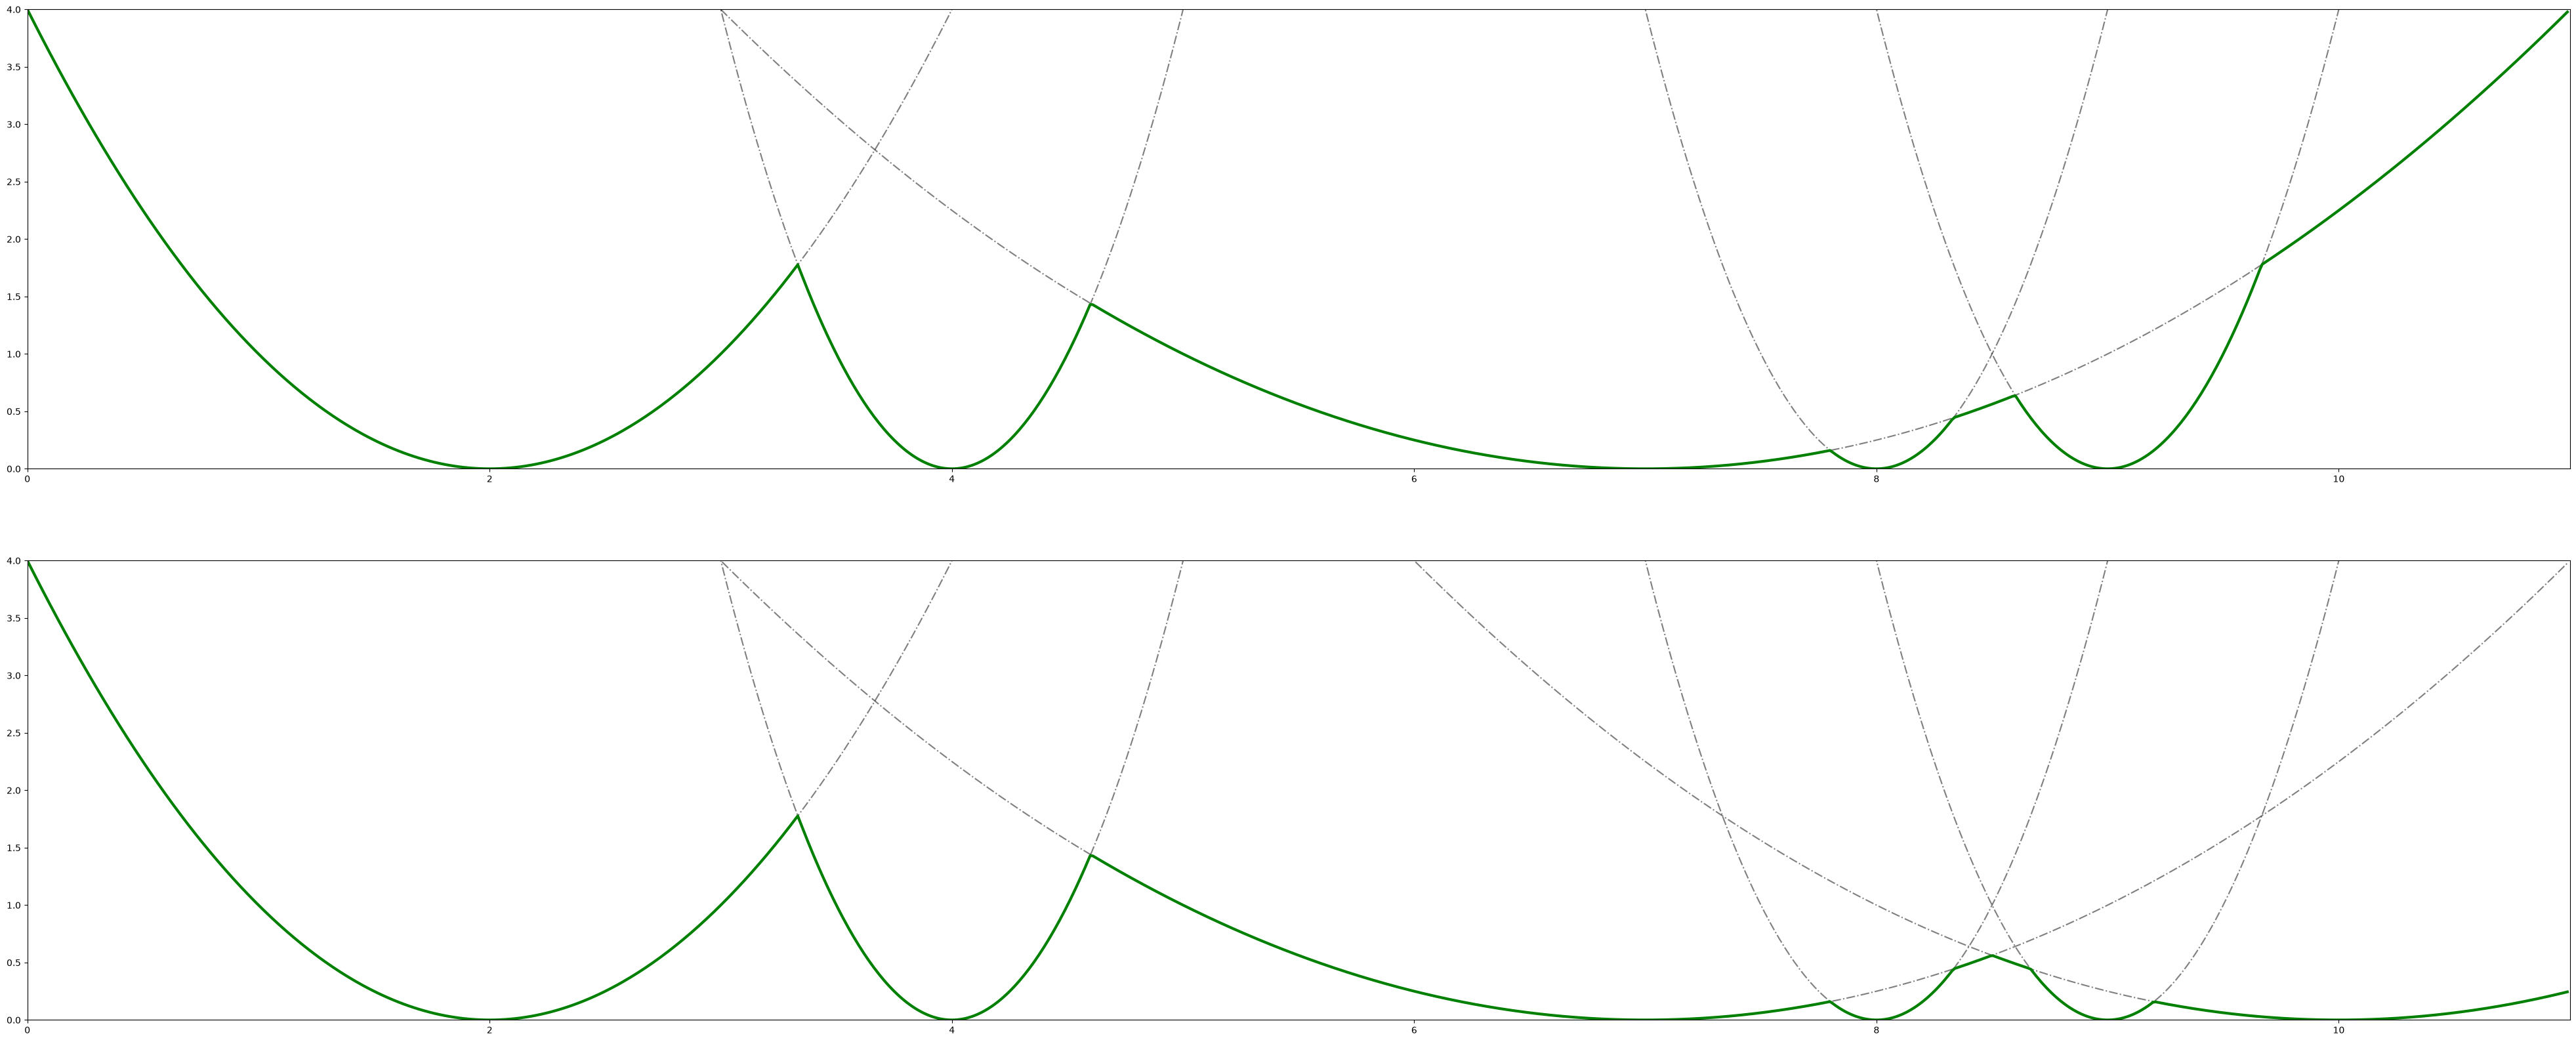

In [ ]:
width = 50
height = 10
my_range = (0, 11)

data = {(1, 2): [Interval(0, 10./3)],
        (2, 4): [Interval(10./3, 4.6)],
        (.5, 7): [Interval(4.6, 7.8), Interval(25./3, 8.6), Interval(29./3, 11)],
        (2, 8): [Interval(7.8, 25./3)],
        (2, 9): [Interval(8.6, 29./3)]}

#values_taken = [-4, -3.356, -2.5, -2.4, -1, 2, 8, 10, 13.24]
x = np.linspace(*my_range, 1000, endpoint=False)

power = lambda e: lambda x: x**e
f = power(2)
string = "x^2"

subplots = 1
fig, ax = plt.subplots(subplots, 1, figsize=(width, subplots*height))

hull = HullByParts(f, data)
plot_draw_bis(ax, x, hull, draw_value_curves=True, curbs_to_add=[(.5, 10)])
    
fig.show()

/tmp/ipykernel_1539416/3760548315.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


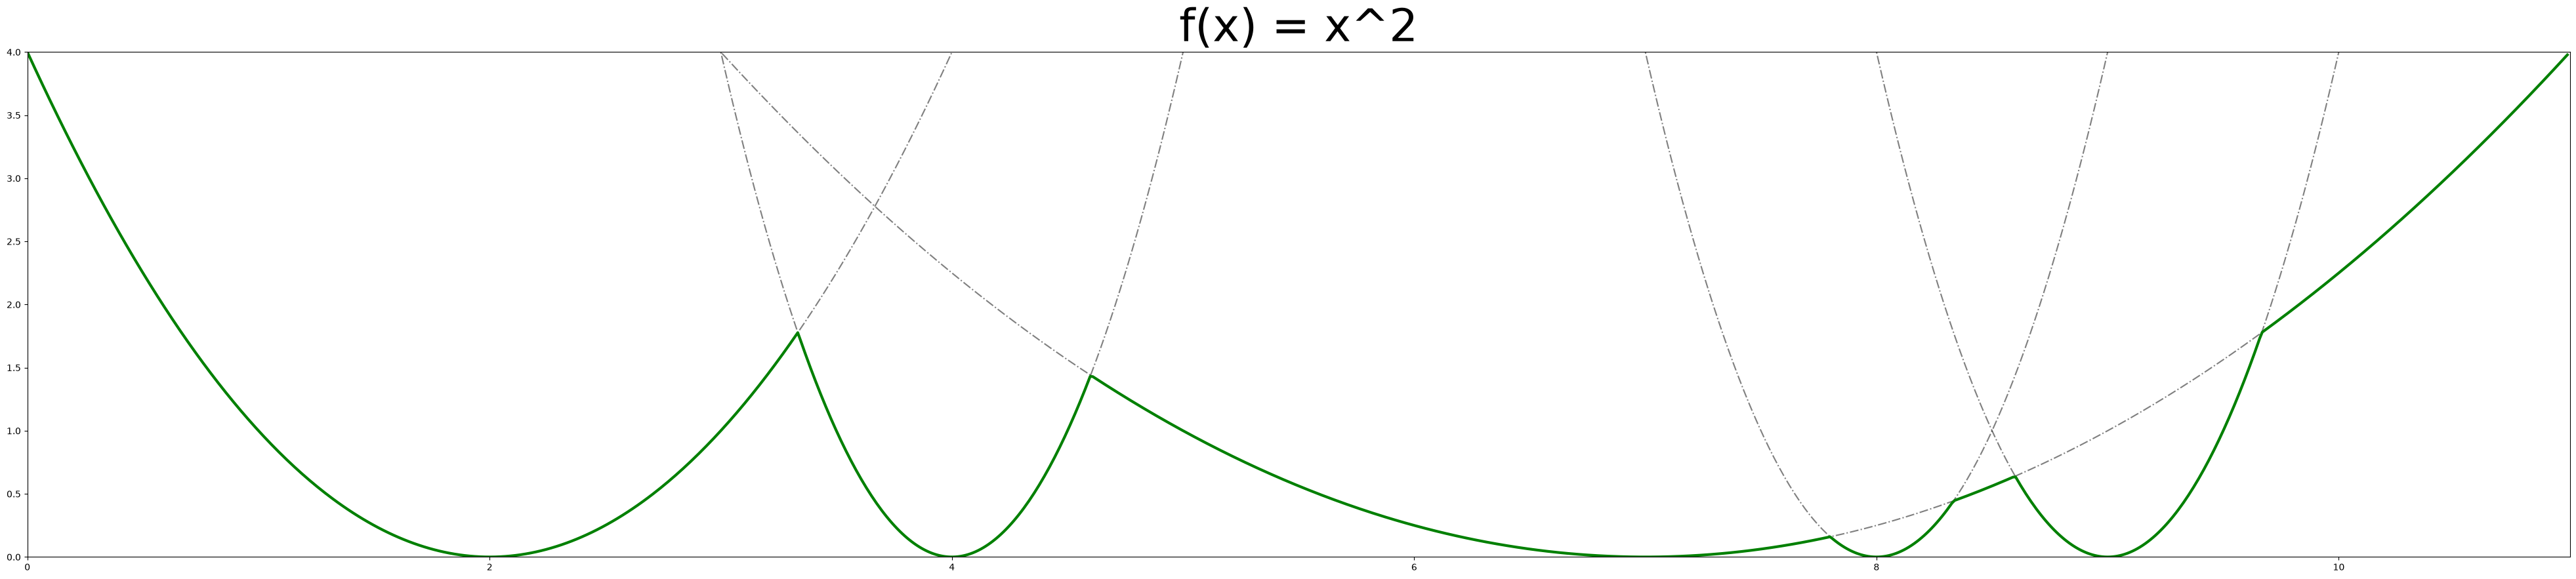

In [ ]:
width = 50
height = 10
my_range = (0, 11)

#values_taken = [-4, -3.356, -2.5, -2.4, -1, 2, 8, 10, 13.24]


x = np.linspace(*my_range, 1000, endpoint=False)

power = lambda e: lambda x: x**e
distance_functions = [power(2)]
functions_expression = ["x^2"]

subplots = len(distance_functions)
fig, axs = plt.subplots(subplots, 1, figsize=(width, subplots*height))


for ax, f, string in zip([axs], distance_functions, functions_expression):
    plot_draw(ax, x, HullByParts(f, data), draw_value_curves=True)
    ax.set_title(label=f"f(x) = {string}", fontdict={'fontsize':50})

fig.show()

In [26]:
a = [1]*5 + [2]*7 + [4] + [3]*15

for i, o in enumerate(a):
    if o == 2:
        a.pop(i)
print(a)

[1, 1, 1, 1, 1, 2, 2, 2, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
